<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/Module2_Exercise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1:** Load an image and apply a thresholding method. Analyze and discuss the segmentation results.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


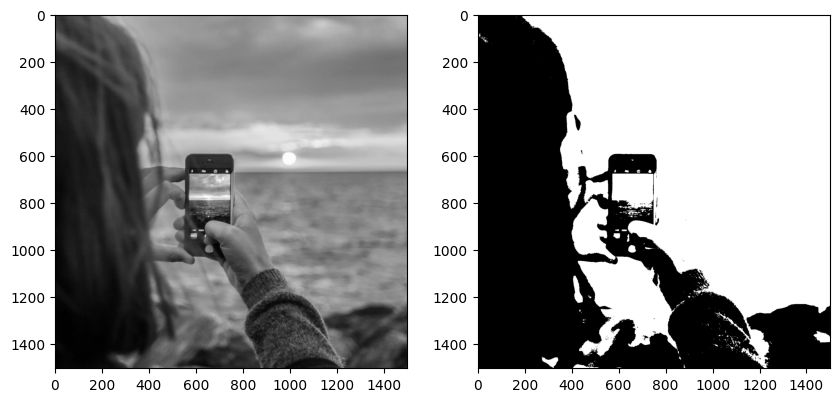

In [32]:
import skimage as sk
from skimage import io
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from google.colab import drive
drive.mount('/content/drive')
img=sk.io.imread("/content/drive/MyDrive/Colab Notebooks/beach_photos.webp")
img_gray=rgb2gray(img);
threeshold=threshold_otsu(img_gray)
image_binary=img_gray>threeshold
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_gray,cmap=plt.cm.gray)
axes[1].imshow(image_binary,cmap=plt.cm.gray)
plt.show()



Since we are using Otsu thresholding, which is an automatic thresholding method, the algorithm finds the optimal threshold value that best separates the object from the background. From the output, we can see that the object the girl with the phone is successfully separated from the background.

**Task 2** Load an image and apply an unsupervised segmentation method (e.g., K-Means). Evaluate and comment on the outcome.

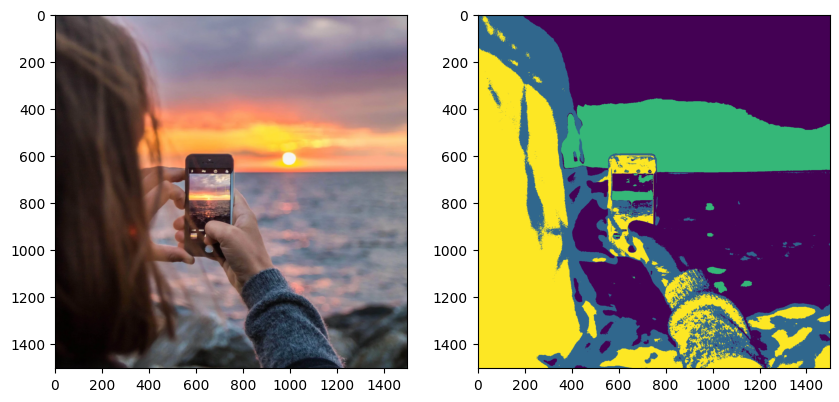

In [33]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
K=4
v_img=np.reshape(img,(img.shape[0]*img.shape[1],img.shape[2]))
kmeans=KMeans(n_clusters=K,random_state=0).fit(v_img)
v_kmeans=kmeans.predict(v_img)
v_kmeans=np.reshape(v_kmeans,(img.shape[0],img.shape[1]))
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[1].imshow(v_kmeans)
plt.show()

We can see that the image is segmented into different regions using K-Means clustering. Pixels with similar intensity or color values are grouped into the same cluster which helps separate different parts of the image.This method is easy but we have to becareful with the number of cluster to optimize.K-Means does not understand spatial structure, only pixel features (color/intensity), so it may produce noisy or fragmented regions

**Task 3:** Load an image and apply a supervised segmentation method (e.g., with annotated labels or using a classifier). Discuss the effectiveness and limitations.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(np.float64(-0.5), np.float64(328.5), np.float64(325.5), np.float64(-0.5))

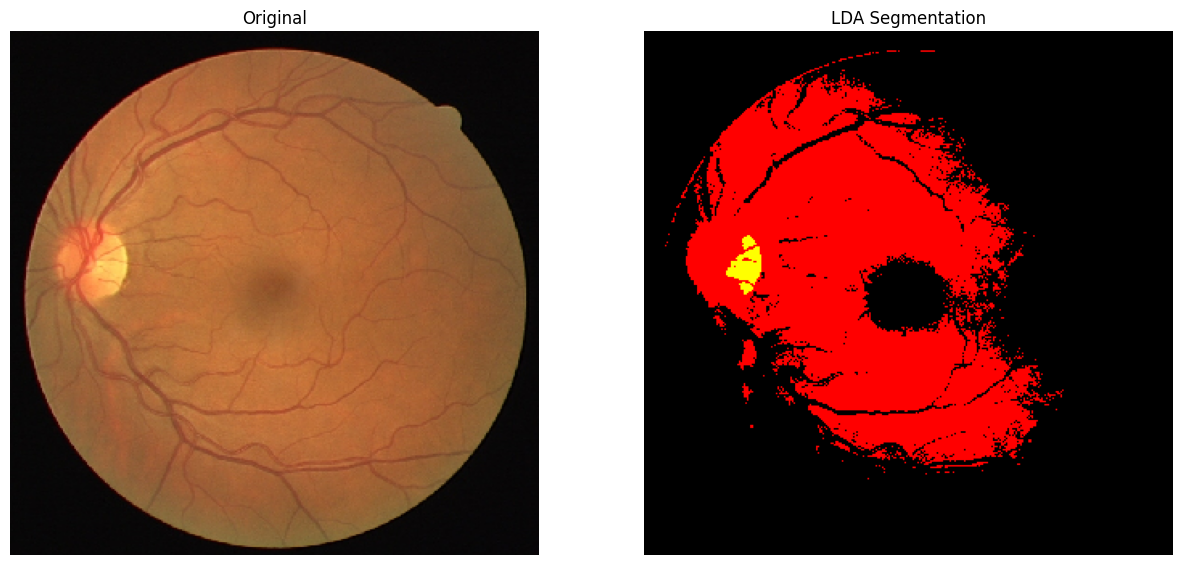

In [34]:
import skimage as sk
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import os
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/'
I_train = sk.io.imread(os.path.join(path, 'photo.png'))
I_train_GT = sk.io.imread(os.path.join(path, 'photo_mask.png'))
if I_train_GT.shape != I_train.shape:
    I_train_GT = sk.transform.resize(I_train_GT, I_train.shape, preserve_range=True)
v_I_train = I_train.reshape(-1, 1).astype(np.uint8)
v_train_GT = I_train_GT.reshape(-1, 1).astype(np.uint8)
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(v_I_train, v_train_GT.ravel())
v_lda = lda_model.predict(v_I_train)
I_lda = v_lda.reshape(I_train.shape)
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(I_train, cmap='gray')
ax[0].set_title("Original")
ax[0].axis('off')
ax[1].imshow(I_lda, cmap='gray')
ax[1].set_title("LDA Segmentation")
ax[1].axis('off')

**Task 4**  Explain the main differences between supervised and unsupervised segmentation approaches. Discuss their advantages and disadvantages, and illustrate your explanation with an example.

Unsupervised segmentation is a type of image segmentation where the model does not use labeled data. Instead, it groups pixels based on similarities such as color, intensity, or texture, and discovers patterns automatically.

Supervised segmentation is a type of segmentation where labeled data is used during training. Each pixel (or region) has a known class label, and the model learns a mapping from input features X to output labels Y, allowing it to predict the correct class for new images.

EXAMPLE: Unsupervised:Segmenting an image of iris eye using K-clustering.
Supervised:Segmenting a satelite photo using classifier trained with images labeled by experts.

